In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("raw_datasets/polaris/antiviral_admet_2025_unblinded.csv")

In [3]:
df

,CXSMILES,HLM,KSOL,LogD,MDR1-MDCKII,MLM,Molecule Name,Set
0,COC1=CC=CC(Cl)=C1NC(=O)N1CCC[C@H](C(N)=O)C1 |a...,NaN,NaN,0.3,2.0,NaN,ASAP-0032437,Train
1,O=C(NCC(F)F)[C@H](NC1=CC2=C(C=C1Br)CNC2)C1=CC(...,NaN,333.0,2.9,0.2,NaN,ASAP-0031915,Train
2,O=C(NCC(F)F)[C@H](NC1=CC=C2CNCC2=C1)C1=CC(Br)=...,NaN,NaN,0.4,0.5,NaN,ASAP-0031884,Train
3,NC(=O)[C@H]1CCCN(C(=O)CC2=CC=CC3=C2C=CO3)C1 |&...,NaN,376.0,1.0,8.5,NaN,ASAP-0031848,Train
4,CC1=CC(CC(=O)N2CCC[C@H](C(N)=O)C2)=CC=N1 |&1:11|,NaN,375.0,-0.3,0.9,NaN,ASAP-0031813,Train
...,...,...,...,...,...,...,...,...
555,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,85.0,NaN,1.1,9.9,80.0,ASAP-0014770,Test
556,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,48.0,347.0,1.1,3.9,102.0,ASAP-0014773,Test
557,COC[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN...,156.0,397.0,2.3,2.6,229.0,ASAP-0014789,Test
558,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,406.0,NaN,1.9,2.6,539.0,ASAP-0014632,Test


Let's first drop the rows that don't have HLM values

In [4]:
df_remove = df[["CXSMILES", "HLM", "Molecule Name", "Set"]].dropna().reset_index(drop=True)

In [5]:
df_remove

,CXSMILES,HLM,Molecule Name,Set
0,CN(C1=CC=C2CNCC2=C1)[C@H](C(=O)NCC(F)F)C1=CC(C...,17.1,ASAP-0031351,Train
1,N#CC1=CC2=C(C=C1NC(=O)C1=CC(F)=CC3=C1C=NN3)CNC2,16.7,ASAP-0031265,Train
2,O=C(NC1=CC=C2CNCC2=C1)C1=CC(F)=CC(C2=CNN=C2)=C1,36.3,ASAP-0031004,Train
3,COCCNC(=O)[C@H](NC1=CC=C2CNCC2=C1)C1=CC(Cl)=CC...,19.7,ASAP-0030761,Train
4,O=C(NC1=CC(Br)=C2CNCC2=C1)C1=CC(F)=CC2=C1C=NN2,13.6,ASAP-0030792,Train
...,...,...,...,...
402,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,85.0,ASAP-0014770,Test
403,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,48.0,ASAP-0014773,Test
404,COC[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN...,156.0,ASAP-0014789,Test
405,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,406.0,ASAP-0014632,Test


On the Polaris Dataset page the organizers wrote that for 4 compounds for HLM, the values were not correct since they changed after time, but they kept them for benchmarking. Due to them being incorrect and kept for benchmarking we will remove them from here

In [6]:
to_remove = [
    "CNC(=O)CN1C[C@@]2(C(=O)N(C3=CN=CC4=CC=CC=C34)C[C@@H]2N)C2=CC(Cl)=CC=C2C1=O |a:7,22|",
    "CNCCN1C[C@@]2(C(=O)N(C3=CN=CC4=CC=CC=C34)C[C@@H]2CS(=O)(=O)N(C)C)C2=CC(Cl)=CC=C2C1=O |a:6,21|",
    "C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(CC1=NC=CO1)C(=O)C1=CC=C(F)C=C12 |a:1,16|",
    "C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(CC1=NN(C)C=N1)C(=O)C1=CC=C(F)C=C12 |a:1,16|",
]

df_remove = df_remove[
    ~df_remove["CXSMILES"].isin(to_remove) &
    df_remove["HLM"].notna()
].reset_index(drop=True)

In [7]:
df_remove

,CXSMILES,HLM,Molecule Name,Set
0,CN(C1=CC=C2CNCC2=C1)[C@H](C(=O)NCC(F)F)C1=CC(C...,17.1,ASAP-0031351,Train
1,N#CC1=CC2=C(C=C1NC(=O)C1=CC(F)=CC3=C1C=NN3)CNC2,16.7,ASAP-0031265,Train
2,O=C(NC1=CC=C2CNCC2=C1)C1=CC(F)=CC(C2=CNN=C2)=C1,36.3,ASAP-0031004,Train
3,COCCNC(=O)[C@H](NC1=CC=C2CNCC2=C1)C1=CC(Cl)=CC...,19.7,ASAP-0030761,Train
4,O=C(NC1=CC(Br)=C2CNCC2=C1)C1=CC(F)=CC2=C1C=NN2,13.6,ASAP-0030792,Train
...,...,...,...,...
398,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,85.0,ASAP-0014770,Test
399,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,48.0,ASAP-0014773,Test
400,COC[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN...,156.0,ASAP-0014789,Test
401,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,406.0,ASAP-0014632,Test


Let's add the scaled and unscaled values in their respective columns to be compatible with the rest of the molecules. also drop the two datapoints with 0

In [8]:
def clip_and_log_transform(y: np.ndarray):
    """
    Clip to a detection limit and transform to log10 scale.
    Parameters
    ----------
    y : np.ndarray
        The array to be clipped and transformed.
    """
    y = np.clip(y, a_min=0, a_max=None)
    return np.log10(y + 1)

In [9]:
df_remove["hlm_value_unscaled"] = df_remove["HLM"]

df_remove["hlm_value_unscaled_log10"] = clip_and_log_transform(
    df_remove["hlm_value_unscaled"].to_numpy()
)

In [10]:
df_remove["hlm_value_scaled_high"] = df_remove["HLM"] * 1.028
df_remove["hlm_value_scaled_low"] = df_remove["HLM"] * 0.840

df_remove["hlm_value_scaled_log10_high"] = clip_and_log_transform(
    df_remove["hlm_value_scaled_high"].to_numpy()
)

df_remove["hlm_value_scaled_log10_low"] = clip_and_log_transform(
    df_remove["hlm_value_scaled_low"].to_numpy()
)

In [11]:
df_remove

,CXSMILES,HLM,Molecule Name,Set,hlm_value_unscaled,hlm_value_unscaled_log10,hlm_value_scaled_high,hlm_value_scaled_low,hlm_value_scaled_log10_high,hlm_value_scaled_log10_low
0,CN(C1=CC=C2CNCC2=C1)[C@H](C(=O)NCC(F)F)C1=CC(C...,17.1,ASAP-0031351,Train,17.1,1.257679,17.5788,14.364,1.269018,1.186504
1,N#CC1=CC2=C(C=C1NC(=O)C1=CC(F)=CC3=C1C=NN3)CNC2,16.7,ASAP-0031265,Train,16.7,1.247973,17.1676,14.028,1.259298,1.176901
2,O=C(NC1=CC=C2CNCC2=C1)C1=CC(F)=CC(C2=CNN=C2)=C1,36.3,ASAP-0031004,Train,36.3,1.571709,37.3164,30.492,1.583385,1.498200
3,COCCNC(=O)[C@H](NC1=CC=C2CNCC2=C1)C1=CC(Cl)=CC...,19.7,ASAP-0030761,Train,19.7,1.315970,20.2516,16.548,1.327392,1.244228
4,O=C(NC1=CC(Br)=C2CNCC2=C1)C1=CC(F)=CC2=C1C=NN2,13.6,ASAP-0030792,Train,13.6,1.164353,13.9808,11.424,1.175535,1.094261
...,...,...,...,...,...,...,...,...,...,...
398,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,85.0,ASAP-0014770,Test,85.0,1.934498,87.3800,71.400,1.946354,1.859739
399,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,48.0,ASAP-0014773,Test,48.0,1.690196,49.3440,40.320,1.701948,1.616160
400,COC[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN...,156.0,ASAP-0014789,Test,156.0,2.195900,160.3680,131.040,2.207817,2.120706
401,C[C@H]1CN(C2=CN=CC3=CC=CC=C23)C(=O)[C@@]12CN(C...,406.0,ASAP-0014632,Test,406.0,2.609594,417.3680,341.040,2.621558,2.534077


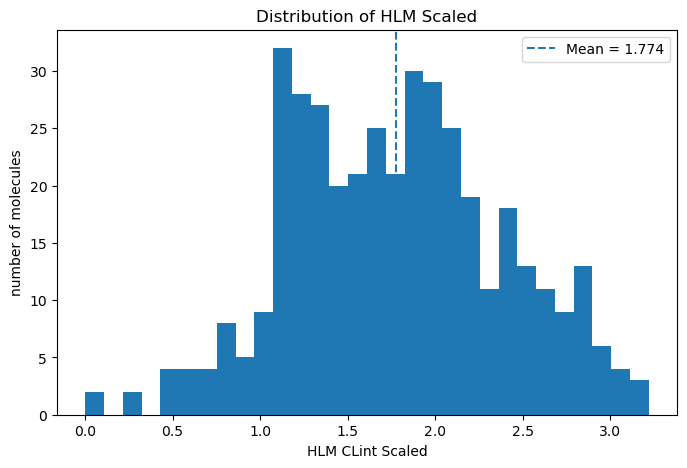

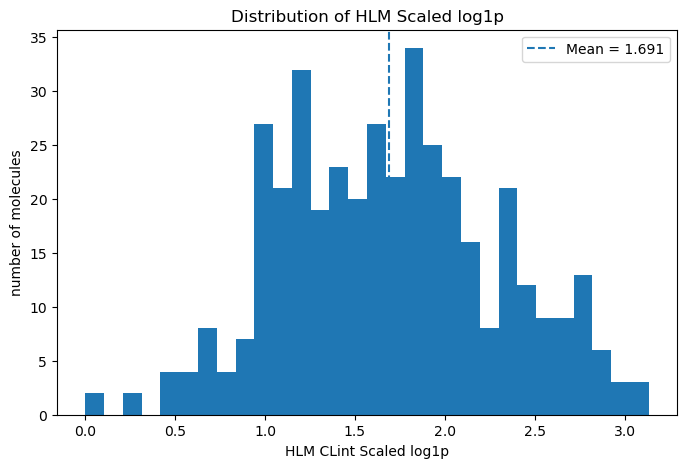

In [12]:
import matplotlib.pyplot as plt

# Mean values
mean_scaled = df_remove["hlm_value_scaled_log10_high"].mean()
mean_scaled_log1p = df_remove["hlm_value_scaled_log10_low"].mean()

# Plot 1: scaled
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled_log10_high"], bins=30)
plt.axvline(mean_scaled, linestyle="--", label=f"Mean = {mean_scaled:.3f}")
plt.xlabel("HLM CLint Scaled")
plt.ylabel("number of molecules")
plt.title("Distribution of HLM Scaled")
plt.legend()
plt.show()

# Plot 2: scaled log10 nan
plt.figure(figsize=(8, 5))
plt.hist(df_remove["hlm_value_scaled_log10_low"], bins=30)
plt.axvline(mean_scaled_log1p, linestyle="--", label=f"Mean = {mean_scaled_log1p:.3f}")
plt.xlabel("HLM CLint Scaled log1p")
plt.ylabel("number of molecules")
plt.title("Distribution of HLM Scaled log1p")
plt.legend()
plt.show()


In [13]:
df_remove["dataset"] = "openadmet_polaris"
df_remove["data_year"] = "2025"
df_remove.to_csv("adjusted_datasets/antiviral_admet_2025_unblinded_adjusted_new.csv")